# 04 — Variant 4: CycleGAN (unpaired)

Trained **without** pairing information (`paired=False`): sketch and color images are
sampled independently — no correspondence signal during training.
Validation and test use `paired=True` so metrics are computed against ground truth.

**Checkpoint comparison**: `val_l1` here measures the unpaired generator's output
against the ground-truth color, which is an external evaluation metric (not a training
signal). Both `last.pt` and `best.pt` are shown for consistency with other variants.

In [1]:
import sys
sys.path.append("..")

import json
from pathlib import Path

import torch
from torch.utils.data import DataLoader

from src.data import AnimeColorizationDataset
from src.training import CycleGANTrainer
from src.utils import (seed_everything, plot_loss_curves, qualitative_grid_compare,
                       cycle_grid, metrics_bar_chart, evaluate_model)

seed_everything(42)

DATA_ROOT = Path("../data/anime_colorization")
CKPT_DIR  = Path("../checkpoints/04_cyclegan")
FIG_DIR   = Path("../results/figures")
TABLE_DIR = Path("../results/tables")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Keep in sync with scripts/train_04_cyclegan.py
CONFIG = dict(
    image_size=256,
    batch_size=8,
    num_workers=8,
    epochs=100,
    decay_start=50,
    lr=2e-4,
    lambda_cycle=10.0,
    lambda_identity=5.0,
    use_amp=True,
    early_stopping=False,
)

## Data

Training is unpaired (`paired=False`). Val / test are paired for metric evaluation.

In [2]:
train_ds = AnimeColorizationDataset(DATA_ROOT, split="train",
                                    image_size=CONFIG["image_size"], paired=False)
val_ds   = AnimeColorizationDataset(DATA_ROOT, split="val",
                                    image_size=CONFIG["image_size"], paired=True)
test_ds  = AnimeColorizationDataset(DATA_ROOT, split="test",
                                    image_size=CONFIG["image_size"], paired=True)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"],
                          shuffle=True,  num_workers=CONFIG["num_workers"],
                          pin_memory=True, drop_last=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=CONFIG["num_workers"],
                          pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=CONFIG["num_workers"],
                          pin_memory=True, persistent_workers=True)

print(f"train: {len(train_ds):,} images (unpaired)")
print(f"val:   {len(val_ds):,} images (paired)")
print(f"test:  {len(test_ds):,} images (paired)")

train: 14,224 images (unpaired)
val:   1,772 images (paired)
test:  1,773 images (paired)


## Training

Training was run headless via `scripts/train_04_cyclegan.py`.
This notebook only loads the resulting checkpoints for evaluation.

In [3]:
def make_trainer():
    return CycleGANTrainer(
        train_loader=train_loader,
        val_loader=val_loader,
        checkpoint_dir=CKPT_DIR,
        monitor="val_l1",
        device="cuda",
        lambda_cycle=CONFIG["lambda_cycle"],
        lambda_identity=CONFIG["lambda_identity"],
        lr=CONFIG["lr"],
        decay_start=CONFIG["decay_start"],
        use_amp=CONFIG["use_amp"],
        early_stopping=CONFIG["early_stopping"],
    )

trainer = make_trainer()
trainer.load_checkpoint("last.pt")
print(f"last.pt — epoch {trainer.epoch}/{CONFIG['epochs']} | best val_l1={trainer.best_metric:.4f}")

last.pt — epoch 100/100 | best val_l1=0.1867


## Loss curves

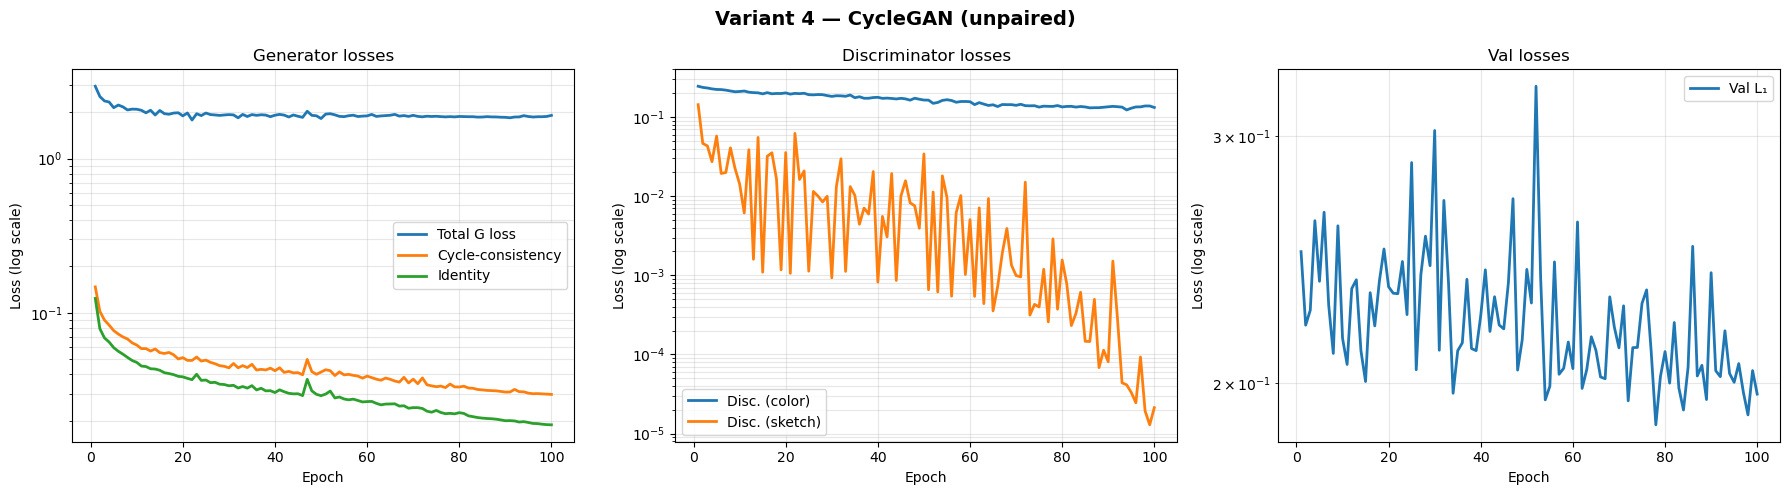

In [4]:
plot_loss_curves(trainer.history,
                 title="Variant 4 — CycleGAN (unpaired)",
                 save_path=FIG_DIR / "04_cyclegan_losses.png")

## Qualitative results — last.pt vs best.pt

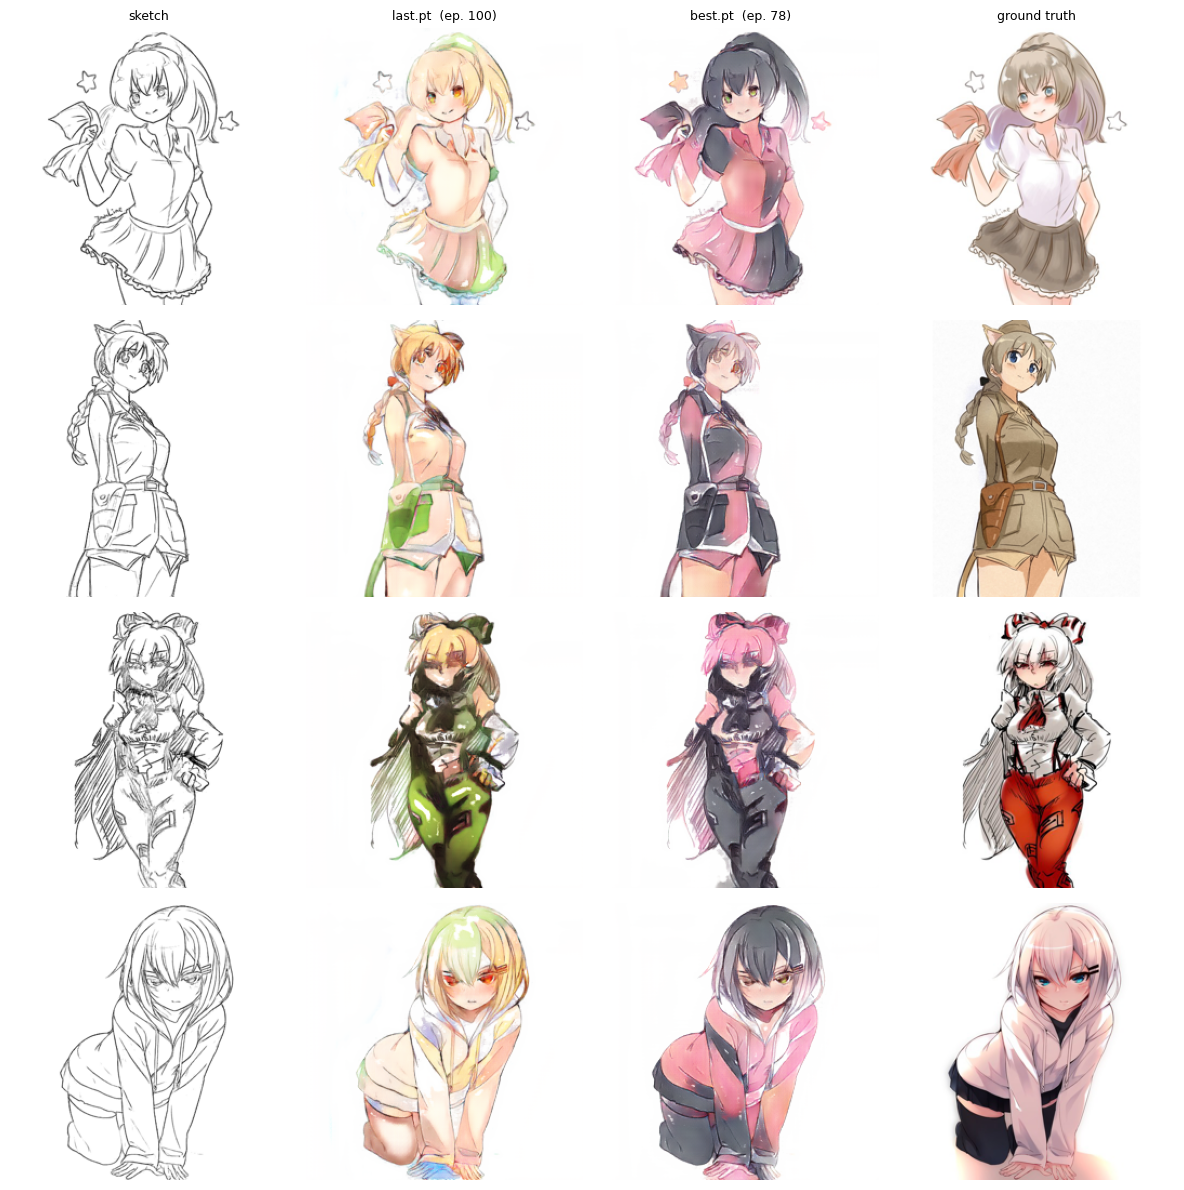

In [5]:
batch = next(iter(test_loader))

epoch_last = trainer.epoch
with torch.no_grad():
    pred_last = trainer.generate(batch["sketch"])

trainer.load_checkpoint("best.pt")
epoch_best = trainer.epoch
with torch.no_grad():
    pred_best = trainer.generate(batch["sketch"])

qualitative_grid_compare(
    batch["sketch"], pred_last, pred_best, batch["color"],
    epoch_last=epoch_last, epoch_best=epoch_best, n_rows=4,
    save_path=FIG_DIR / "04_cyclegan_grid.png",
)

## Cycle reconstruction — forward cycle (best.pt)

Visualization of the CycleGAN forward cycle: **sketch → G_s2c → fake color → G_c2s → reconstructed sketch**.

If `rec. sketch ≈ sketch` but `fake color` has wrong colors, this proves that
cycle-consistency is satisfied even with incorrect colorization — the model
learned an invertible mapping, not the correct one.

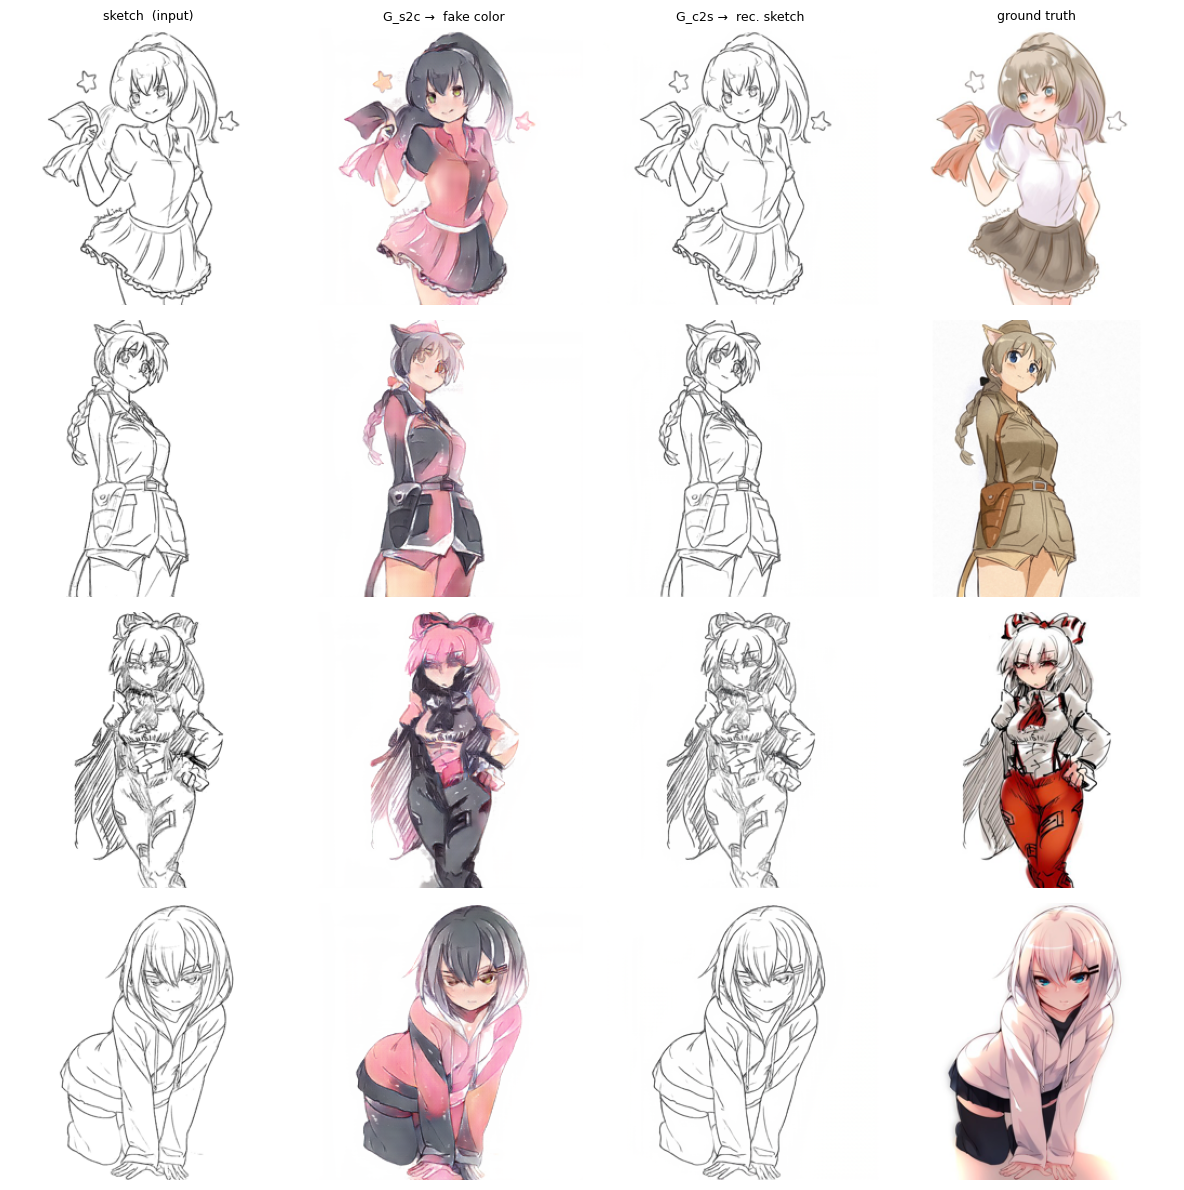

In [6]:
# best.pt is already loaded from the cell above
with torch.no_grad():
    fake_color_cycle = trainer.G_s2c(batch["sketch"].to(trainer.device)).cpu()
    rec_sketch_cycle = trainer.G_c2s(fake_color_cycle.to(trainer.device)).cpu()

cycle_grid(
    batch["sketch"], fake_color_cycle, rec_sketch_cycle, batch["color"],
    n_rows=4,
    save_path=FIG_DIR / "04_cyclegan_cycle.png",
)

## Quantitative evaluation (test set)

Generator: `trainer.G_s2c` (sketch → color direction).

/data/aidawks/conda-envs/anime-colorization/lib/python3.10/site-packages/torchmetrics/functional/image/lpips.py:332: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_

metric       last.pt     best.pt       delta
psnr         13.7865     14.4947     +0.7082
ssim          0.7726      0.7725     -0.0001
lpips         0.2372      0.2341     -0.0031
fid          57.6568     39.5111    -18.1456


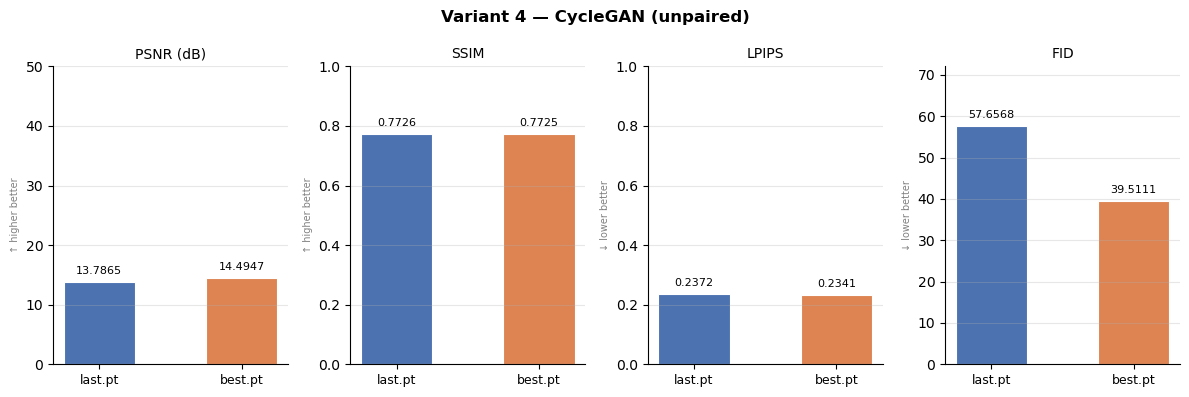

In [5]:
trainer.load_checkpoint("last.pt")
metrics_last = evaluate_model(trainer.G_s2c, test_loader,
                              fid_dir="../results/fid/04_cyclegan_last")

trainer.load_checkpoint("best.pt")
metrics_best = evaluate_model(trainer.G_s2c, test_loader,
                              fid_dir="../results/fid/04_cyclegan_best")

print(f"{'metric':8s}  {'last.pt':>10s}  {'best.pt':>10s}  {'delta':>10s}")
for k in metrics_last:
    delta = metrics_best[k] - metrics_last[k]
    print(f"{k:8s}  {float(metrics_last[k]):>10.4f}  {float(metrics_best[k]):>10.4f}  {float(delta):>+10.4f}")

metrics_bar_chart(
    {"last": metrics_last, "best": metrics_best},
    title="Variant 4 — CycleGAN (unpaired)",
    save_path=FIG_DIR / "04_cyclegan_metrics.png",
)

with open(TABLE_DIR / "04_cyclegan.json", "w") as f:
    json.dump({"variant": "04_cyclegan", "config": CONFIG,
               "metrics": {"last": metrics_last, "best": metrics_best}}, f, indent=2)